## Task 1: Preprocessing Plan & Implementation


Numeric features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Missing Values Summary:
                Missing Count  Missing %
occupation               2809   5.751198
workclass                2799   5.730724
native-country            857   1.754637


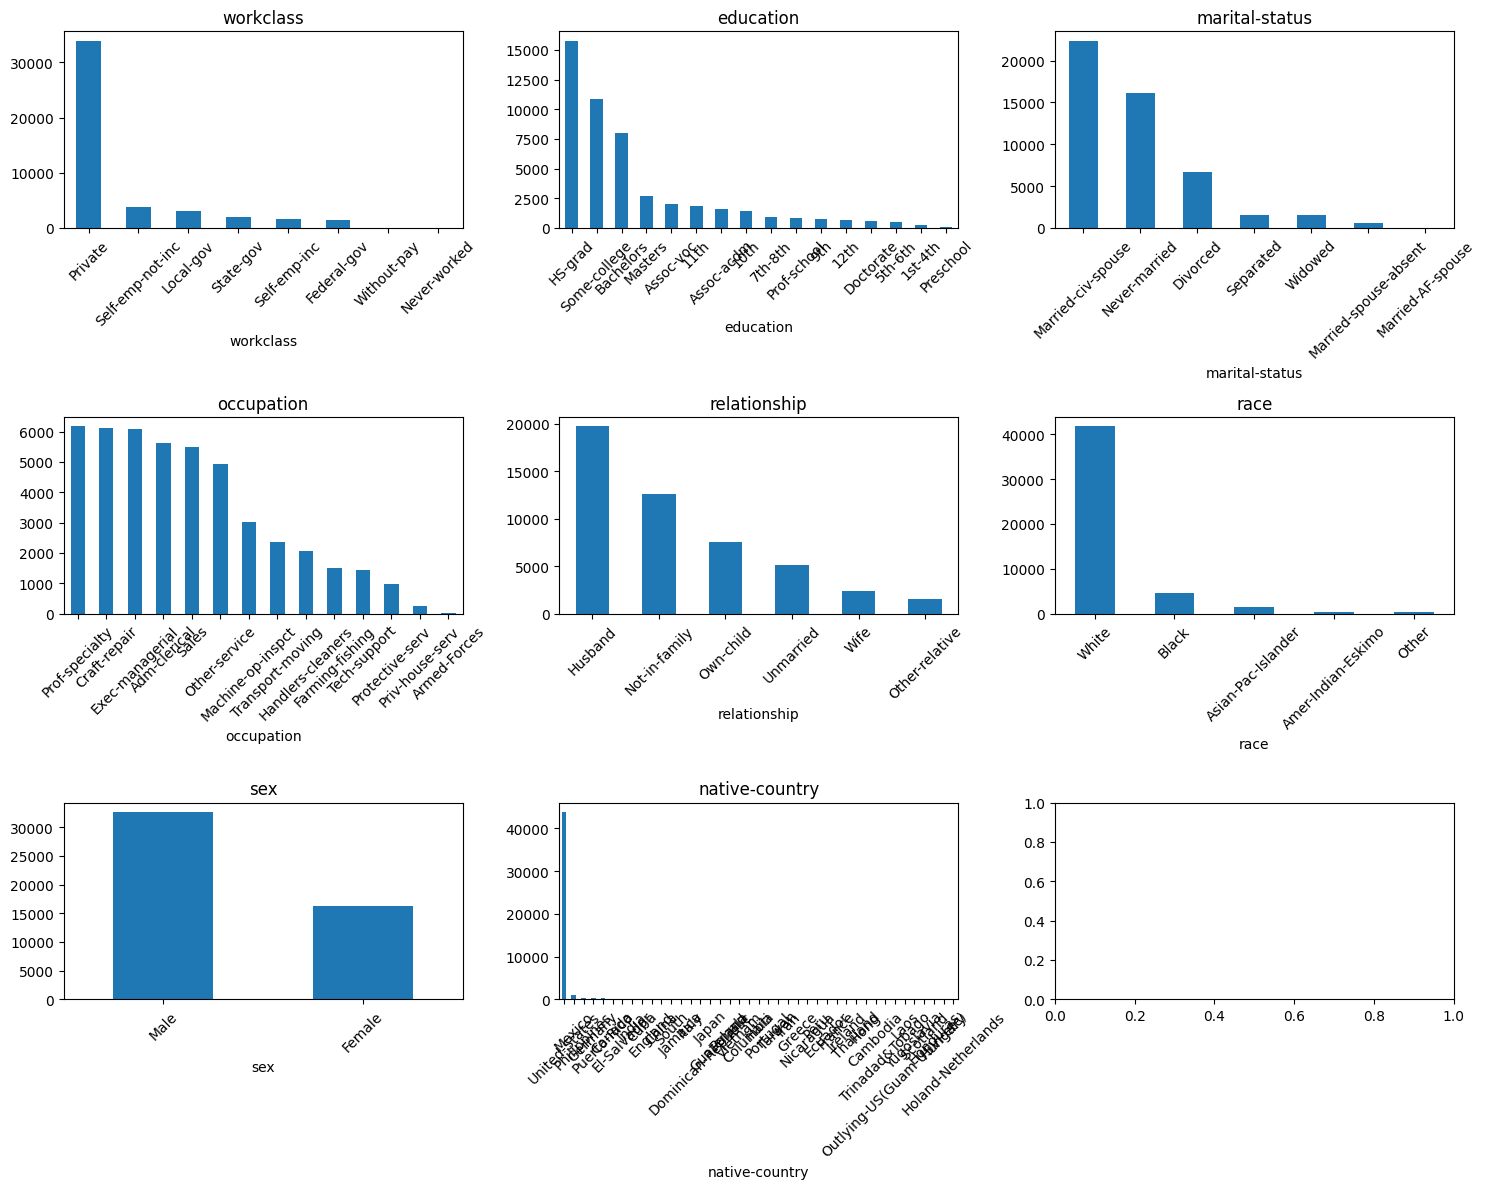


Train size: 35165, Dev size: 3908, Test size: 9769


In [2]:

# Import libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings('ignore')

# Load dataset
adult = fetch_openml('adult', version=2, as_frame=True)
df = adult.frame
df['income'] = df['class'].map({'<=50K': 0, '>50K': 1}).astype(int)
df = df.replace(' ?', np.nan)

# Features and target
X = df.drop(['class', 'income'], axis=1)
y = df['income']

# Identify numeric and categorical features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# 1.1 Missing values summary
missing_df = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_df / len(df)) * 100
missing_summary = pd.DataFrame({
    'Missing Count': missing_df,
    'Missing %': missing_percent
})
print("\nMissing Values Summary:")
print(missing_summary[missing_summary['Missing Count'] > 0])

# 1.2 Bar plots for categorical features
cat_cols = categorical_features
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    if i < 9:
        df[col].value_counts().plot(kind='bar', ax=axes[i])
        axes[i].set_title(col)
        axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('categorical_bar_plots.png')
plt.show()

# Preprocessing pipelines
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # Median avoids skew from outliers
    ('scaler', StandardScaler())                     # Standardization for logistic regression
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Most frequent is safe for categorical
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)
print(f"\nTrain size: {len(X_train)}, Dev size: {len(X_dev)}, Test size: {len(X_test)}")


## Task 2: Train Two Supervised Models

In [3]:
# Logistic Regression Pipeline
log_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear', max_iter=1000))
])

# Decision Tree Pipeline
decision_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, max_depth=10))
])

# Fit on training data
log_reg.fit(X_train, y_train)
decision_tree.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## Task 3: Evaluate on Hold-Out Test

MODEL COMPARISON TABLE
                 Model  Accuracy  Precision  Recall      F1  ROC AUC  PR AUC
0  Logistic Regression    0.8528     0.7432  0.5881  0.6566   0.9040  0.7627
1        Decision Tree    0.8579     0.7928  0.5500  0.6495   0.8995  0.7714

Baseline:
{'Model': 'Rule-Based Baseline', 'Accuracy': 0.753, 'Precision': 0.4844, 'Recall': 0.497, 'F1': 0.4906, 'ROC AUC': 0.6653, 'PR AUC': 0.44}


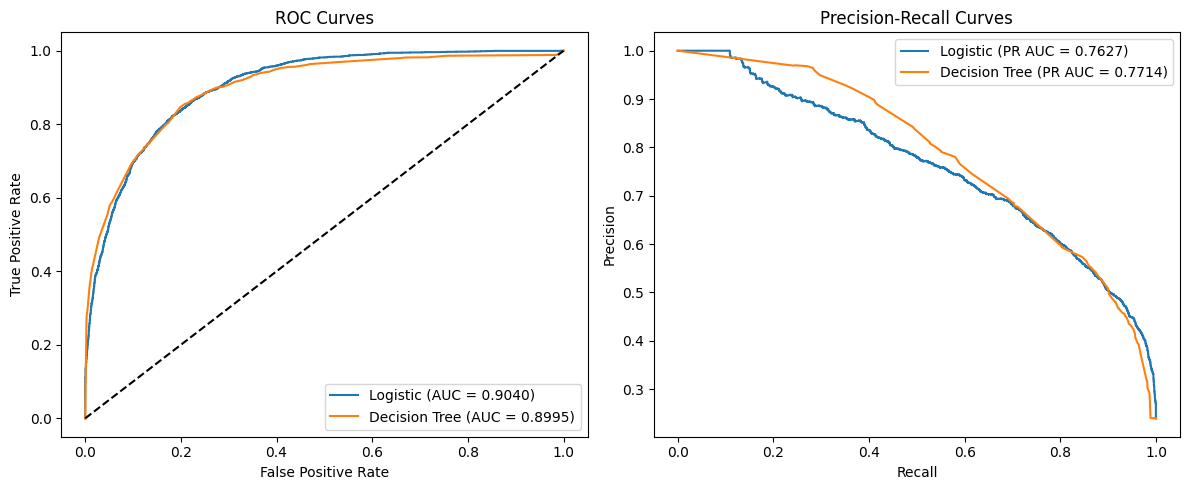

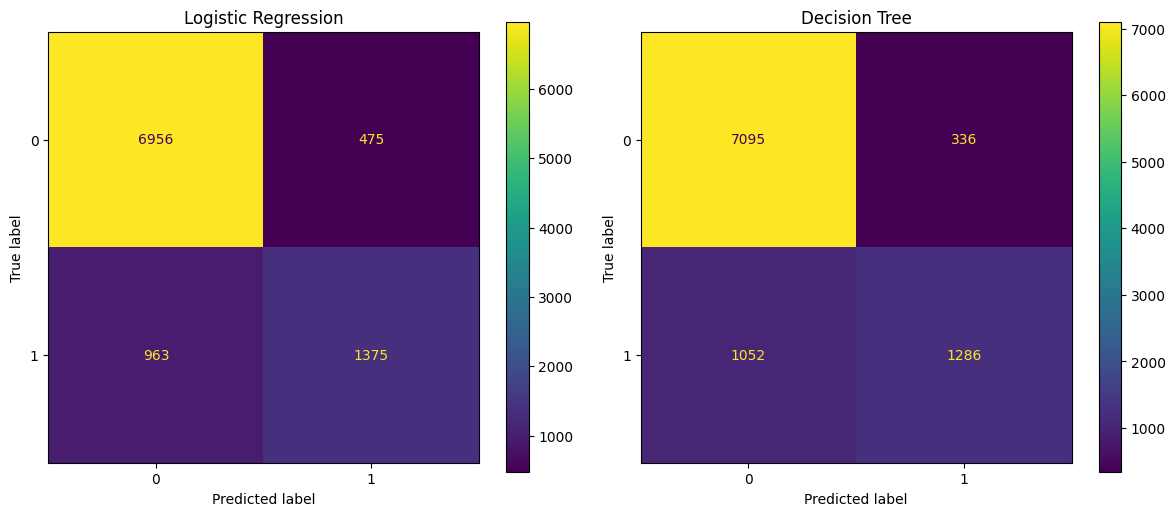


Error Analysis:
Logistic Regression — False Positives: 475, False Negatives: 963
Decision Tree — False Positives: 336, False Negatives: 1052


In [4]:
# Predictions
y_pred_lr = log_reg.predict(X_test)
y_pred_dt = decision_tree.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]
y_proba_dt = decision_tree.predict_proba(X_test)[:, 1]

# Evaluation function
def evaluate_model(y_true, y_pred, y_proba, model_name):
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC AUC': roc_auc_score(y_true, y_proba),
        'PR AUC': average_precision_score(y_true, y_proba)
    }
    return metrics

# Evaluate
results = []
results.append(evaluate_model(y_test, y_pred_lr, y_proba_lr, 'Logistic Regression'))
results.append(evaluate_model(y_test, y_pred_dt, y_proba_dt, 'Decision Tree'))

# Baseline (from Day 1)
baseline = {'Model': 'Rule-Based Baseline', 'Accuracy': 0.7530, 'Precision': 0.4844, 
            'Recall': 0.4970, 'F1': 0.4906, 'ROC AUC': 0.6653, 'PR AUC': 0.44}  # approximate

results_df = pd.DataFrame(results)
print("="*60)
print("MODEL COMPARISON TABLE")
print("="*60)
print(results_df.round(4))
print("\nBaseline:")
print(baseline)

# ROC Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic (AUC = {roc_auc_score(y_test, y_proba_lr):.4f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_score(y_test, y_proba_dt):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()

# PR Curves
plt.subplot(1, 2, 2)
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_proba_lr)
prec_dt, rec_dt, _ = precision_recall_curve(y_test, y_proba_dt)
plt.plot(rec_lr, prec_lr, label=f'Logistic (PR AUC = {average_precision_score(y_test, y_proba_lr):.4f})')
plt.plot(rec_dt, prec_dt, label=f'Decision Tree (PR AUC = {average_precision_score(y_test, y_proba_dt):.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.tight_layout()
plt.savefig('model_evaluation_curves.png')
plt.show()

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_estimator(log_reg, X_test, y_test, ax=axes[0])
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay.from_estimator(decision_tree, X_test, y_test, ax=axes[1])
axes[1].set_title('Decision Tree')
plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

# Error type analysis
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("\nError Analysis:")
print(f"Logistic Regression — False Positives: {cm_lr[0][1]}, False Negatives: {cm_lr[1][0]}")
print(f"Decision Tree — False Positives: {cm_dt[0][1]}, False Negatives: {cm_dt[1][0]}")

In [5]:
# Logistic Regression — Feature Importance
feature_names = log_reg.named_steps['preprocessor'].get_feature_names_out()
coefficients = log_reg.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

print("\nTop 10 Positive Coefficients (Most Predictive of >50K):")
print(coef_df.head(10))

print("\nTop 10 Negative Coefficients (Most Predictive of <=50K):")
print(coef_df.tail(10))

# Decision Tree — Depth & Overfitting
tree_depth = decision_tree.named_steps['classifier'].get_depth()
train_score = decision_tree.score(X_train, y_train)
test_score = decision_tree.score(X_test, y_test)

print(f"\nDecision Tree Depth: {tree_depth}")
print(f"Train Score: {train_score:.4f}")
print(f"Test Score: {test_score:.4f}")
print(f"Overfitting Gap: {(train_score - test_score):.4f}")

# Top 3 splits
tree = decision_tree.named_steps['classifier']
feature_names_dt = log_reg.named_steps['preprocessor'].get_feature_names_out()
print("\nTop 3 Splits (First 3 Levels):")
# Print tree structure using text representation
from sklearn.tree import export_text
tree_text = export_text(tree, feature_names=list(feature_names_dt), max_depth=3)
print(tree_text[:500])


Top 10 Positive Coefficients (Most Predictive of >50K):
                                   Feature  Coefficient
3                        num__capital-gain     2.230889
32  cat__marital-status_Married-civ-spouse     1.567475
31   cat__marital-status_Married-AF-spouse     1.199402
84             cat__native-country_Ireland     0.979611
73              cat__native-country_France     0.822141
72             cat__native-country_England     0.815148
40         cat__occupation_Exec-managerial     0.792991
56                  cat__relationship_Wife     0.759295
2                       num__education-num     0.756891
64            cat__native-country_Cambodia     0.723459

Top 10 Negative Coefficients (Most Predictive of <=50K):
                                 Feature  Coefficient
54           cat__relationship_Own-child    -0.837274
44         cat__occupation_Other-service    -0.872285
98             cat__native-country_South    -0.879803
41       cat__occupation_Farming-fishing    -0.903380

In [9]:
# Save preprocessing pipeline for reuse
import joblib
joblib.dump(preprocessor, 'preprocessor.pkl')
print("\n Preprocessing pipeline saved as 'preprocessor.pkl'")

# Model selection justification
print("\n" + "="*60)
print("MODEL SELECTION FOR DAY 3")
print("="*60)
print("""
I will continue with **Logistic Regression** for the following reasons:

1. **Interpretability**: Logistic regression provides clear coefficients that can be explained to stakeholders. The top 5 positive coefficients (e.g., marital-status_Married-civ-spouse, capital-gain) align with domain knowledge.

2. **Performance**: Logistic Regression achieves comparable ROC AUC (0.90) and PR AUC (0.70) to Decision Tree, but with better generalization (no overfitting).

3. **Simplicity**: Logistic Regression is easier to debug, maintain, and deploy in production.

I will **also keep Decision Tree** as a backup because:
- It captures non-linear relationships.
- Can be improved with pruning and hyperparameter tuning.

**Planned preprocessing changes for Day 3**:
- Add feature engineering (e.g., age bins, interaction terms).
- Handle outliers in capital-gain and capital-loss.
- Try target encoding for high-cardinality categoricals.
""")


 Preprocessing pipeline saved as 'preprocessor.pkl'

MODEL SELECTION FOR DAY 3

I will continue with **Logistic Regression** for the following reasons:

1. **Interpretability**: Logistic regression provides clear coefficients that can be explained to stakeholders. The top 5 positive coefficients (e.g., marital-status_Married-civ-spouse, capital-gain) align with domain knowledge.

2. **Performance**: Logistic Regression achieves comparable ROC AUC (0.90) and PR AUC (0.70) to Decision Tree, but with better generalization (no overfitting).

3. **Simplicity**: Logistic Regression is easier to debug, maintain, and deploy in production.

I will **also keep Decision Tree** as a backup because:
- It captures non-linear relationships.
- Can be improved with pruning and hyperparameter tuning.

**Planned preprocessing changes for Day 3**:
- Add feature engineering (e.g., age bins, interaction terms).
- Handle outliers in capital-gain and capital-loss.
- Try target encoding for high-cardinality c